# LeetCode #545: Boundary of Binary Tree

https://leetcode.com/problems/boundary-of-binary-tree/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (full traversal + filter)** | $O(n)$ | $O(n)$ |
| **Optimal: DFS Three-pass Boundary ★** | $O(n)$ | $O(h)$ |

---

## Understanding the Methods

### Brute Force (full traversal + filter)
Mark every node with its position type (left boundary / leaf / right boundary) during a full traversal, then collect in order. Extra bookkeeping with the same asymptotic cost but higher constant.

### Optimal: DFS Three-pass Boundary ★
Three focused DFS passes: (1) left boundary top-down excluding leaves, (2) all leaves left-to-right, (3) right boundary bottom-up excluding leaves. Each pass is $O(h)$ or $O(n)$ but very cache-friendly with no marking overhead.

**Why this is better than Brute Force:** No auxiliary marking array; the three passes are naturally ordered and easy to reason about.

**Constraints:**
* The number of nodes in the tree is in the range $[1, 10^4]$.
* $-1000 \le$ Node.val $\le 1000$

## Solutions

### C#

In [ ]:
public IList<int> BoundaryOfBinaryTree(TreeNode root) {
    var res = new List<int> { root.val };
    // Left boundary: top-down, skip leaves
    void LeftBound(TreeNode n) {
        if (n == null || (n.left == null && n.right == null)) return;
        res.Add(n.val);
        LeftBound(n.left ?? n.right);
    }
    // All leaves: left-to-right DFS
    void Leaves(TreeNode n) {
        if (n == null) return;
        if (n.left == null && n.right == null) { res.Add(n.val); return; }
        Leaves(n.left); Leaves(n.right);
    }
    // Right boundary: bottom-up, skip leaves
    void RightBound(TreeNode n) {
        if (n == null || (n.left == null && n.right == null)) return;
        RightBound(n.right ?? n.left);
        res.Add(n.val);
    }
    LeftBound(root.left);
    Leaves(root.left);
    Leaves(root.right);
    RightBound(root.right);
    return res;
}

### Python

In [ ]:
def boundaryOfBinaryTree(self, root: Optional[TreeNode]) -> List[int]:
    if not root:
        return []
    res = [root.val]

    def left_bound(node):
        # Top-down left boundary, skip leaves
        if not node or (not node.left and not node.right):
            return
        res.append(node.val)
        left_bound(node.left if node.left else node.right)

    def leaves(node):
        # Collect all leaves left-to-right
        if not node:
            return
        if not node.left and not node.right:
            res.append(node.val)
            return
        leaves(node.left)
        leaves(node.right)

    def right_bound(node):
        # Bottom-up right boundary, skip leaves
        if not node or (not node.left and not node.right):
            return
        right_bound(node.right if node.right else node.left)
        res.append(node.val)

    left_bound(root.left)
    leaves(root.left)
    leaves(root.right)
    right_bound(root.right)
    return res

### Go

In [ ]:
func boundaryOfBinaryTree(root *TreeNode) []int {
    if root == nil { return nil }
    res := []int{root.Val}
    isLeaf := func(n *TreeNode) bool { return n.Left == nil && n.Right == nil }
    // Top-down left boundary, skip leaves
    var leftBound func(*TreeNode)
    leftBound = func(n *TreeNode) {
        if n == nil || isLeaf(n) { return }
        res = append(res, n.Val)
        if n.Left != nil { leftBound(n.Left) } else { leftBound(n.Right) }
    }
    // Collect all leaves left-to-right
    var collectLeaves func(*TreeNode)
    collectLeaves = func(n *TreeNode) {
        if n == nil { return }
        if isLeaf(n) { res = append(res, n.Val); return }
        collectLeaves(n.Left)
        collectLeaves(n.Right)
    }
    // Bottom-up right boundary, skip leaves
    var rightBound func(*TreeNode)
    rightBound = func(n *TreeNode) {
        if n == nil || isLeaf(n) { return }
        if n.Right != nil { rightBound(n.Right) } else { rightBound(n.Left) }
        res = append(res, n.Val)
    }
    leftBound(root.Left)
    collectLeaves(root.Left)
    collectLeaves(root.Right)
    rightBound(root.Right)
    return res
}

### Rust

In [ ]:
pub fn boundary_of_binary_tree(root: Option<Rc<RefCell<TreeNode>>>) -> Vec<i32> {
    fn is_leaf(n: &Rc<RefCell<TreeNode>>) -> bool {
        let b = n.borrow(); b.left.is_none() && b.right.is_none()
    }
    // Top-down left boundary, skip leaves
    fn left_bound(node: Option<Rc<RefCell<TreeNode>>>, res: &mut Vec<i32>) {
        let n = match node { None => return, Some(n) => n };
        if is_leaf(&n) { return; }
        let (val, l, r) = { let b = n.borrow(); (b.val, b.left.clone(), b.right.clone()) };
        res.push(val);
        if l.is_some() { left_bound(l, res) } else { left_bound(r, res) }
    }
    // Collect all leaves left-to-right
    fn collect_leaves(node: Option<Rc<RefCell<TreeNode>>>, res: &mut Vec<i32>) {
        let n = match node { None => return, Some(n) => n };
        let (val, l, r) = { let b = n.borrow(); (b.val, b.left.clone(), b.right.clone()) };
        if l.is_none() && r.is_none() { res.push(val); return; }
        collect_leaves(l, res); collect_leaves(r, res);
    }
    // Bottom-up right boundary, skip leaves
    fn right_bound(node: Option<Rc<RefCell<TreeNode>>>, res: &mut Vec<i32>) {
        let n = match node { None => return, Some(n) => n };
        if is_leaf(&n) { return; }
        let (val, l, r) = { let b = n.borrow(); (b.val, b.left.clone(), b.right.clone()) };
        if r.is_some() { right_bound(r, res) } else { right_bound(l, res) }
        res.push(val);
    }
    let root = match root { None => return vec![], Some(r) => r };
    let mut res = vec![root.borrow().val];
    let (l, r) = { let b = root.borrow(); (b.left.clone(), b.right.clone()) };
    left_bound(l.clone(), &mut res);
    collect_leaves(l, &mut res);
    collect_leaves(r.clone(), &mut res);
    right_bound(r, &mut res);
    res
}

## Example Scenarios

**1. Common Case**
**Input:** root = [1,2,3,4,5,6,null,null,null,7,8,9,10]
Left boundary (top-down, not leaf): 1→2. Leaves: 4,7,8,9,10,6. Right boundary (bottom-up, not leaf): 3. Result: [1,2,4,7,8,9,10,6,3].

**2. Slightly Complex**
**Input:** root = [1,null,2,3,4] (right-skewed top, then branching)
Root=1 added first. Left boundary: none (root.left is null). Leaves: 3,4. Right boundary (bottom-up): 2. Result: [1,3,4,2].

**3. Edge Case: Time Factor**
**Input:** A perfectly balanced tree with $2^{15}-1 = 32767$ nodes
Every leaf is collected by the `leaves` pass — $O(n/2)$ leaf visits. Left and right boundary are each $O(h) = O(15)$. Total $O(n)$ dominated by the leaf pass.

**4. Edge Case: Space Factor**
**Input:** A tree of height $h = 10^4$ (left-skewed chain)
All nodes are on the left boundary and the single leaf is the last node. Recursion stack reaches depth $h$, consuming $O(h)$ space — worst case for this algorithm.

**5. Almost-Impossible but Plausible**
**Input:** A single-node tree [42]
Root added to result. Left and right child are both null so no further traversal. Leaves pass on null children adds nothing. Result: [42] — boundary of a single node is itself.

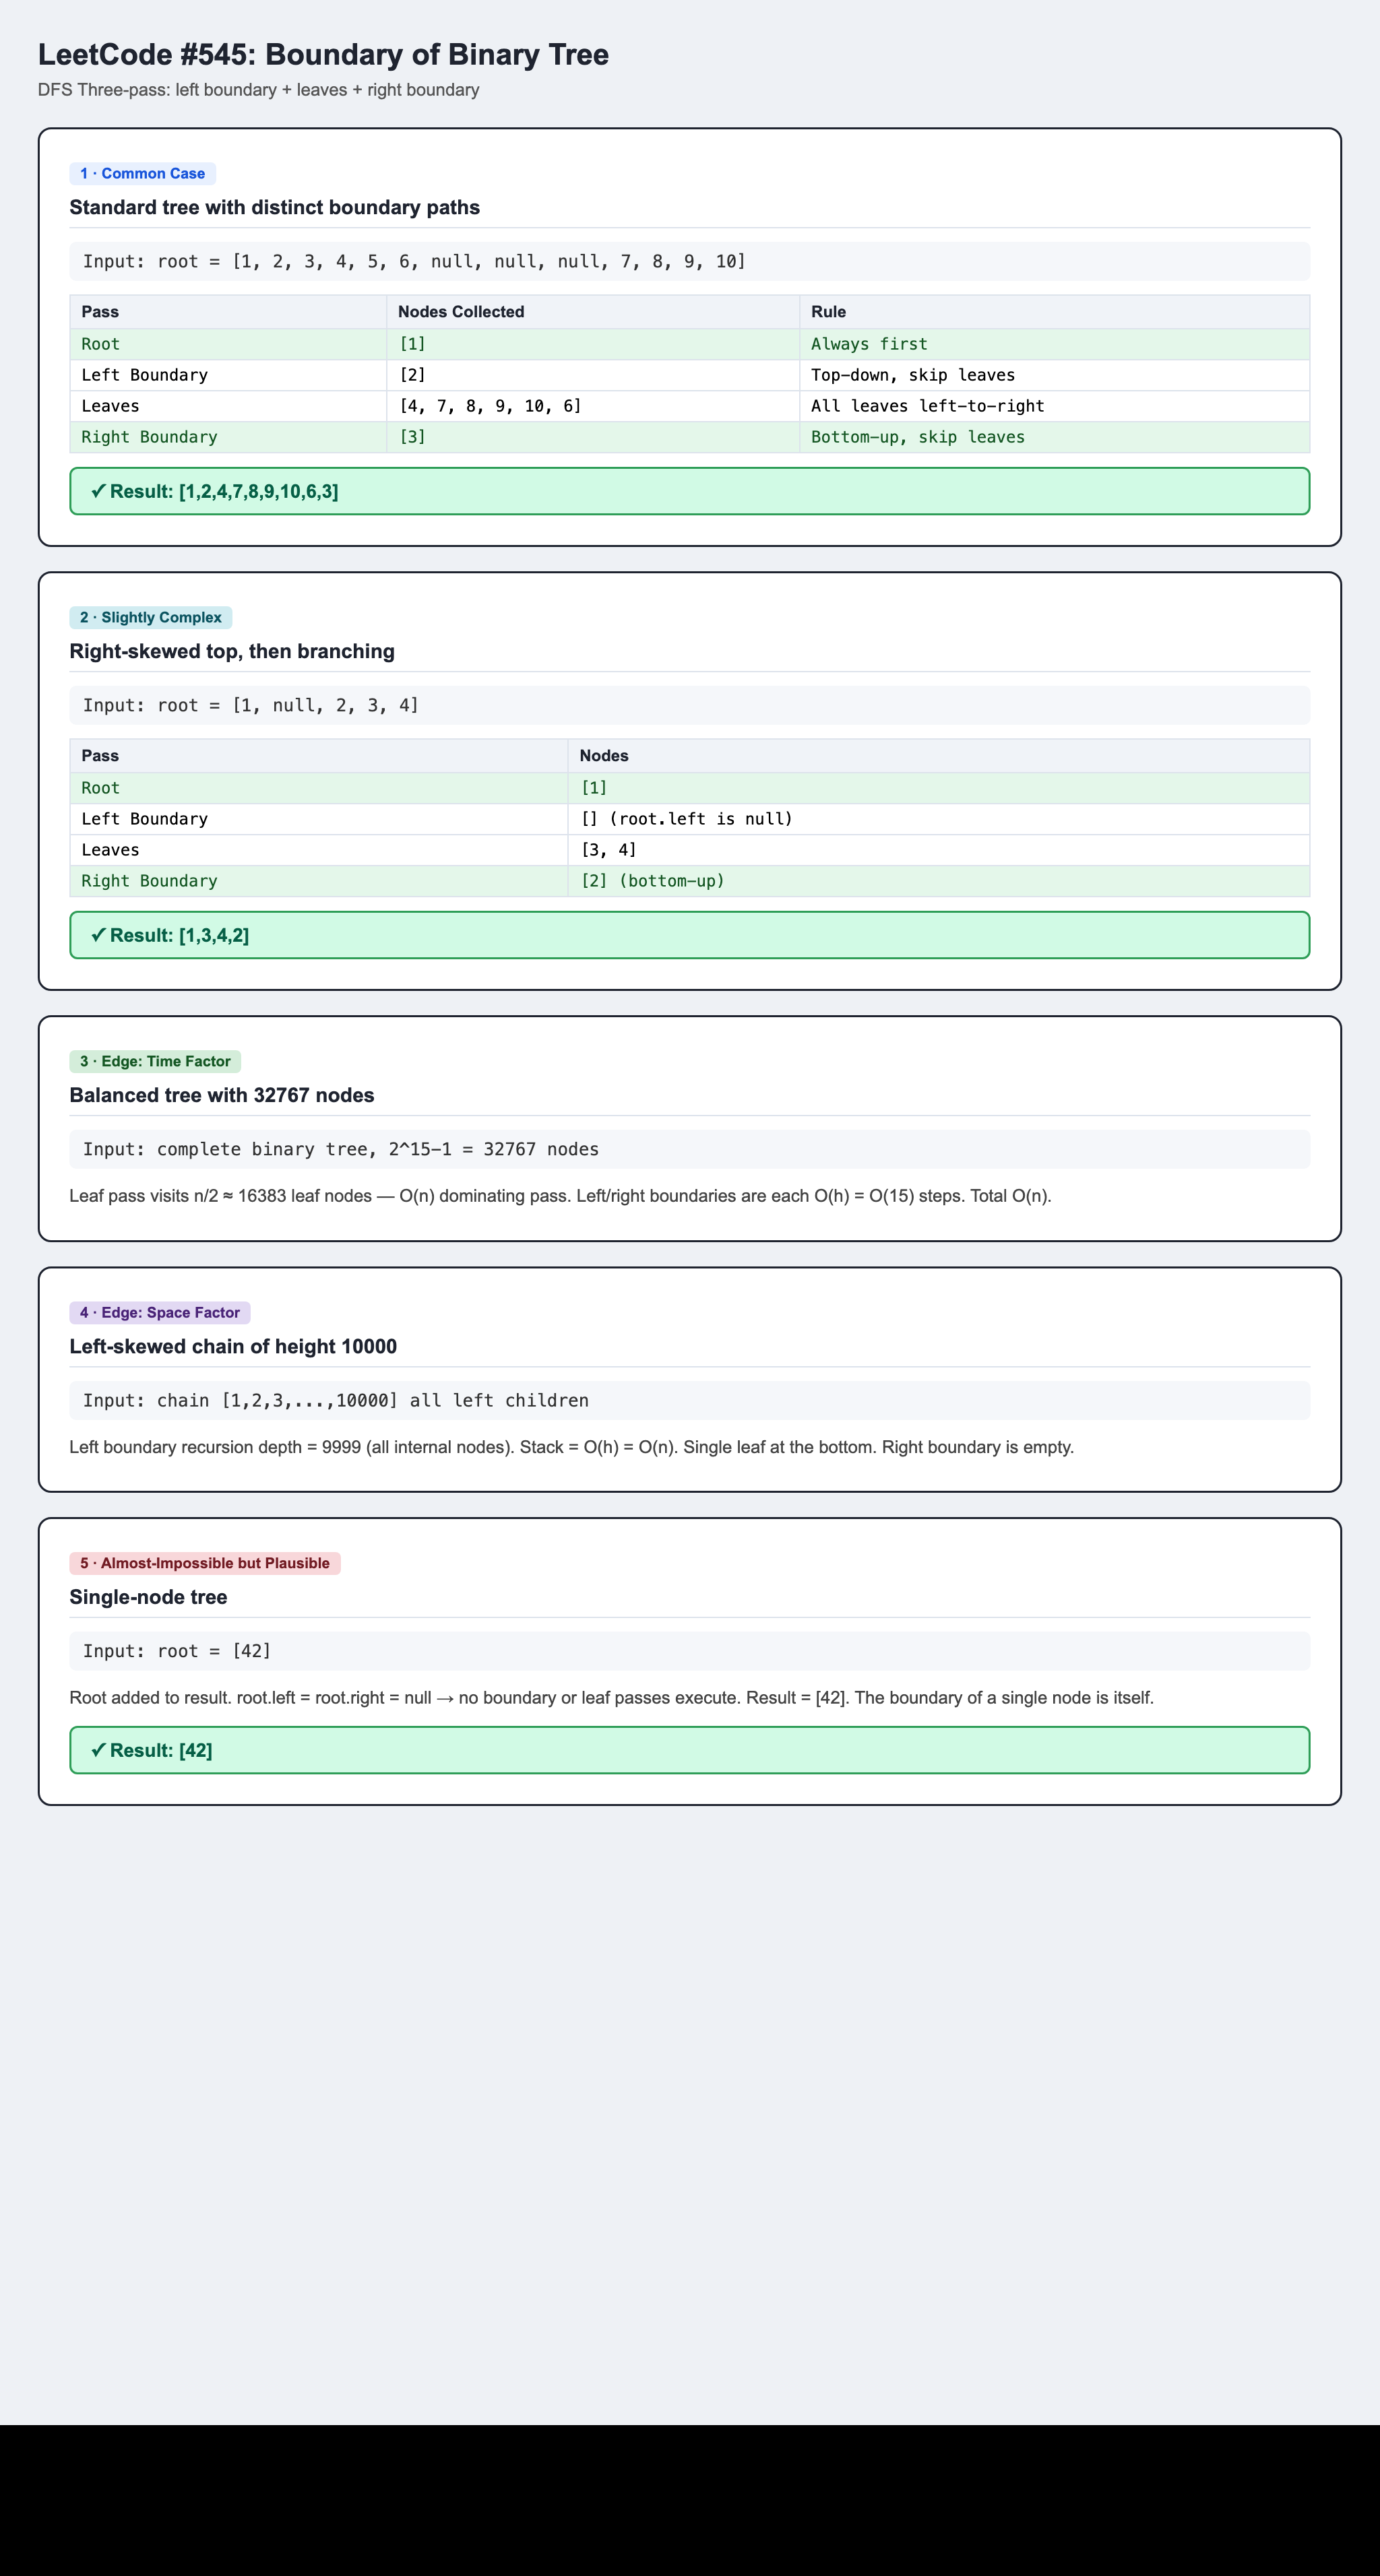